#UCR STAT 206 Final Project
##Hotel Booking Cancellations
##Group 7 - Pycraft
Group Members: Yared Mekbib, Meghana Penugonda, Edris Flores
Date: March 19, 2026

#Intro

We investigate hotel booking cancellations using the Hotel Booking Demand dataset. The outcome of interest is whether a booking was canceled. We focus on booking characteristics that may be related to cancellations and that could matter for hotel operations and revenue planning.

Our main question is: What factors are most strongly associated with booking cancellations and can we predict cancellation rates consistently?

We specifically examine lead time, deposit type, repeat guest status, and whether cancellation patterns differ between city and resort hotels. 


#Dataset Description

We use two related datasets: H1 contains resort hotel bookings and H2 contains city hotel bookings. This is appropriate for our question as it includes enough data to create a predictive model.

These datasets include lead time, arrival date information, number of nights, number of guests, deposit type, market segment, average daily rate, and cancellation status. 

We combine them and add a hotel type indicator.

In [4]:
#Set up imports and paths for report
import sys
from pathlib import Path

# report folder is one level below project root, so we need to add project root to path to import src modules
project_root = Path().resolve().parents[0]
sys.path.insert(0, str(project_root))

from src.data_io import load_hotel_data
from src.cleaning import clean_hotel_data
from src.features import add_features
from src.models import run_logistic

In [5]:

df_raw = load_hotel_data()
df_clean = clean_hotel_data(df_raw)
df_final = add_features(df_clean)

df_final.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,hotel_type,total_nights,is_family,has_special_requests,total_guests
0,0,342,2015,July,27,1,0,0,2,0.0,...,0.0,0,0,Check-Out,2015-07-01,Resort,0,0,0,2.0
1,0,737,2015,July,27,1,0,0,2,0.0,...,0.0,0,0,Check-Out,2015-07-01,Resort,0,0,0,2.0
2,0,7,2015,July,27,1,0,1,1,0.0,...,75.0,0,0,Check-Out,2015-07-02,Resort,1,0,0,1.0
3,0,13,2015,July,27,1,0,1,1,0.0,...,75.0,0,0,Check-Out,2015-07-02,Resort,1,0,0,1.0
4,0,14,2015,July,27,1,0,2,2,0.0,...,98.0,0,1,Check-Out,2015-07-03,Resort,2,0,1,2.0


#Preprocessing

We followed the pipeline described in our proposal. We combined H1 and H2, standardized fields, handled missing values, and created useful derived variables like total nights (weekend nights plus weekday nights) and total guests (adults plus children plus babies). Listed above are the cleaned data and first five entries.



This keeps the analysis consistent across both hotel types.

#Methods

We use descriptive statistics and visualizations to understand how cancellations vary across booking characteristics. We compare cancellation rates across key categories, compare numeric variables by cancellation status, and use a logistic regression model as a simple way to summarize which factors are most associated with cancellation after controlling for others.

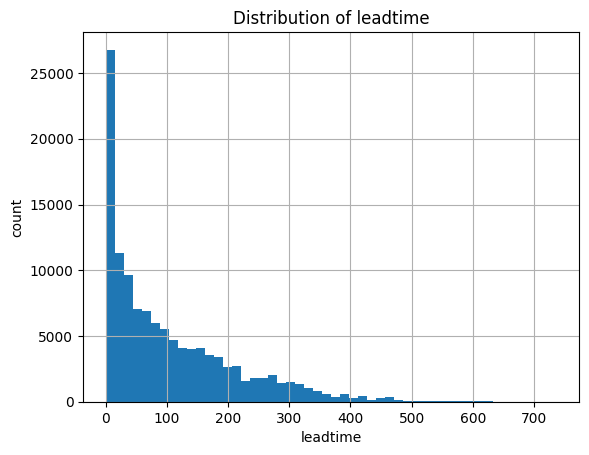

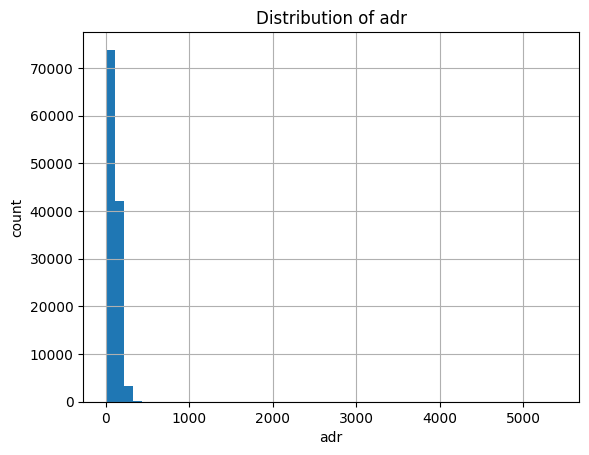

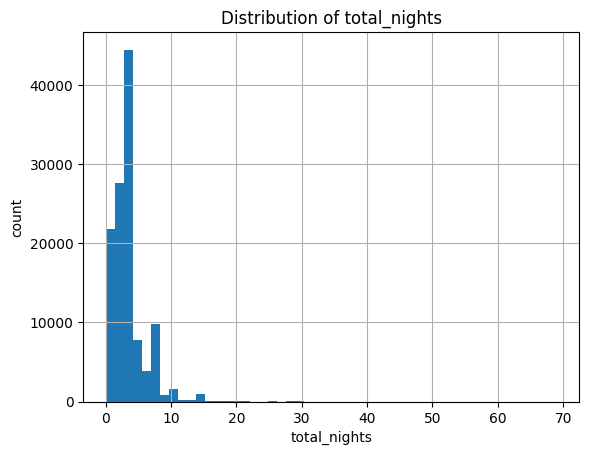

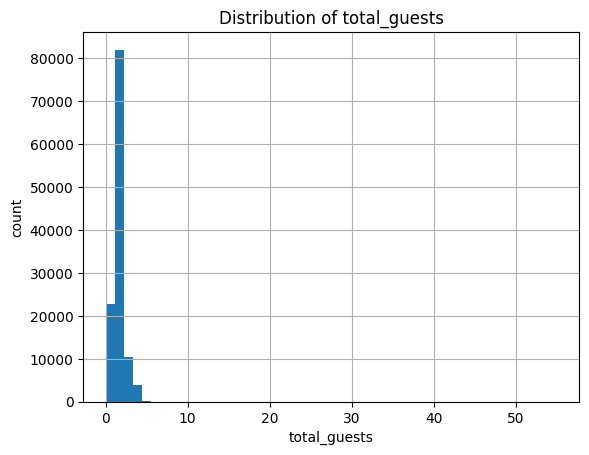

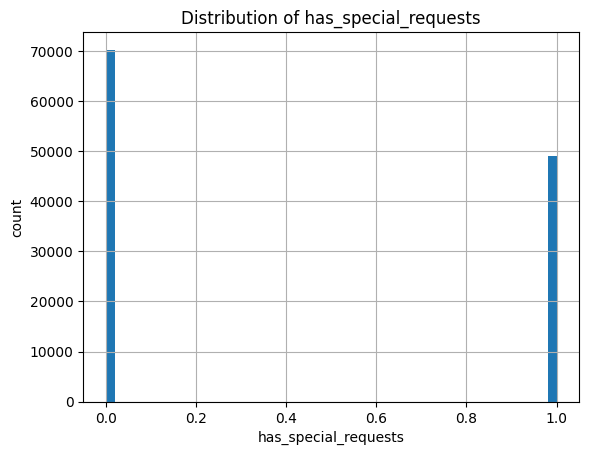

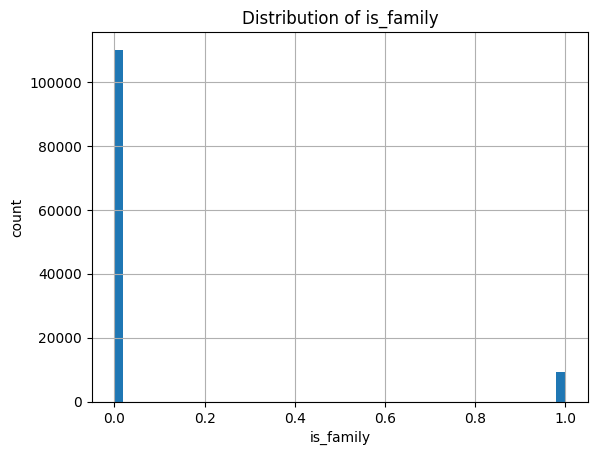

In [8]:
# Distributions

import matplotlib.pyplot as plt

cols = ["leadtime", "adr", "total_nights", "total_guests","has_special_requests", "is_family"]
for c in cols:
    df_final[c].hist(bins=50)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

#Distributions of Key Variables

##Lead Time

The distribution of lead time is clearly right skewed. Most people book within about 100 days of arrival, but there is a long tail where some guests book extremely far in advance. That long tail stretches past 400 days. What this tells us is that while early bookings happen, most customers are not planning that far ahead. Because of this skew, the average can be pulled upward by extreme values, so medians are more reliable when comparing groups.

##ADR

ADR is also heavily right skewed. Most bookings are concentrated at lower price levels, and there are a small number of very high values. Those extreme values likely represent premium rooms or unusual cases. This tells us pricing is not evenly distributed. If we only looked at the mean ADR, it could be misleading because of those high outliers.

##Total Nights

Most stays are short. The majority fall between 1 and 5 nights. There are very few long stays. This shows that typical bookings are short term, and long stays are rare. That is important because extremely long stays could behave differently when modeling cancellations.

##Total Guests

Most bookings involve 1 to 3 guests. Large group bookings are uncommon. This suggests that the dataset is dominated by individuals and small groups. Guest size does not vary dramatically for most bookings. Across all four variables, we see strong right skewness. Because of this, we avoid assuming normal distributions and instead rely on logistic regression and group comparisons that do not require normality.

#Has Special Requests

We can see there are a number of special requests that amount to about 2/3 the amount of bookings with no special requests. The team believes this may influence cancellation rates as an assumption can be made that if you are making a special request you are less likely to cancel.

#Is Family

In this visualization it is clear the vast majority of bookings are with people who do not have children or babies. Perhaps these groups will feature more cancellation rates. Something to be explored.



In [9]:
#Cancellation rates across categories

def cancel_rate_table(df, col):
    return (
        df.groupby(col)["iscanceled"]
          .agg(cancel_rate="mean", n="size")
          .sort_values("cancel_rate", ascending=False)
    )

for c in ["deposittype", "hotel_type", "marketsegment", "customertype", "isrepeatedguest"]:
    display(cancel_rate_table(df_final, c))

,cancel_rate,n
deposittype,,
Non Refund,0.993624,14587
No Deposit,0.283773,104640
Refundable,0.222222,162


,cancel_rate,n
hotel_type,,
City,0.41727,79330
Resort,0.27764,40059


,cancel_rate,n
marketsegment,,
Undefined,1.000000,2
Groups,0.610651,19810
Online TA,0.367211,56477
Offline TA/TO,0.343160,24219
Aviation,0.219409,237
Corporate,0.187347,5295
Direct,0.153419,12606
Complementary,0.130552,743


,cancel_rate,n
customertype,,
Transient,0.407463,89613
Contract,0.309617,4076
Transient-Party,0.254309,25123
Group,0.102253,577


,cancel_rate,n
isrepeatedguest,,
0,0.377851,115580
1,0.144920,3809


#Cancellation Rates Across Categories

To understand what drives cancellations, we calculated cancellation rates across major booking categories. Since the cancellation variable is coded as 0 and 1, the mean within each group directly represents the cancellation rate. This allows us to compare risk across different types of bookings rather than just counting cancellations.

##Deposit Type

Deposit policy has the strongest relationship with cancellations. Non Refund bookings have an extremely high cancellation rate of about 99 percent. In contrast, bookings with no deposit cancel about 28 percent of the time. Refundable deposits cancel at about 22 percent, but the sample size is very small. This suggests deposit structure plays a major role in cancellation behavior. However, the nearly 99 percent cancellation rate for Non Refund bookings may indicate unusual coding or a structural issue in the dataset and should be interpreted carefully.

##Hotel Type

City hotels have a higher cancellation rate at about 41 percent compared to Resort hotels at about 28 percent. This suggests that bookings in city properties are more volatile and more likely to be canceled than resort stays.

##Market Segment

Group bookings have a very high cancellation rate at about 61 percent. Online travel agents and offline agents also show elevated cancellation rates around 34 to 37 percent. Corporate and direct bookings show lower cancellation rates, around 15 to 19 percent. This suggests that the booking channel and customer type strongly influence cancellation behavior.

##Customer Type

Transient customers have the highest cancellation rate at about 41 percent. Contract customers cancel about 31 percent of the time. Group customers cancel the least at about 10 percent, but the sample size is small. This indicates that individual short term travelers are much more likely to cancel compared to structured or contractual bookings.

##Repeat Guest Status

Repeat guests cancel far less frequently. New guests cancel about 38 percent of the time, while repeat guests cancel only about 14 percent of the time. This is a strong signal that loyalty is associated with booking stability.

Overall, deposit type, hotel type, market segment, and repeat guest status all show meaningful differences in cancellation rates. These variables are likely to be important predictors in our logistic regression model.

In [10]:
#Numeric comparisons by cancellation status

summary = (
    df_final.groupby("iscanceled")[["leadtime", "adr", "total_nights", "total_guests"]]
    .agg(["mean", "median"])
)
summary

leadtime                adr        total_nights         \
                  mean median        mean median         mean median   
iscanceled                                                             
0            79.983157   45.0   99.989108   92.5     3.392936    3.0   
1           144.848815  113.0  104.964333   96.2     3.487179    3.0   

           total_guests         
                   mean median  
iscanceled                      
0              1.942460    2.0  
1              2.012052    2.0

#Numeric Comparisons by Cancellation Status

To better understand cancellation behavior, we compared key numeric variables between canceled and non canceled bookings. Because several variables are right skewed, we report both means and medians to avoid distortion from extreme values.

##Lead Time

Lead time shows the strongest difference between groups.

Bookings that were not canceled have a median lead time of 45 days.
Canceled bookings have a median lead time of 113 days.

That is a large difference.

This suggests that customers who book far in advance are much more likely to cancel. The longer the planning window, the greater the uncertainty. Lead time appears to be one of the strongest numeric predictors of cancellation.

##ADR

Canceled bookings have slightly higher prices.

Median ADR:
Not canceled: 92.5
Canceled: 96.2

The difference exists but is modest. Price may contribute to cancellation behavior, but it does not appear to be a primary driver compared to lead time.

##Total Nights

Median total nights is 3 for both groups.

There is almost no separation here. Length of stay alone does not meaningfully differentiate canceled from non canceled bookings.

##Total Guests

Median total guests is 2 for both groups.

Guest count does not appear to strongly influence cancellation likelihood.

Among the numeric variables examined, lead time shows the clearest separation between canceled and non canceled bookings. ADR shows a small difference, while total nights and total guests show minimal impact. This suggests that booking timing plays a more important role in cancellation behavior than trip size or duration.

In [11]:
#Logistic regression 

feature_cols = [
    "leadtime",
    "adr",
    "deposittype",
    "hotel_type",
    "isrepeatedguest",
    "total_nights",
    "total_guests",
    "marketsegment",
    "customertype",
    "is_family",
    "has_special_requests"
]

results = run_logistic(df_final, feature_cols=feature_cols)
results["accuracy"], results["roc_auc"]

(0.7849102117394801, 0.8128710598052933)

We used logistic regression to predict whether a booking would be canceled. The model included lead time, ADR, deposit type, hotel type, repeat guest status, total nights, total guests, market segment, and customer type, is_family, and has_special_requests.

The model achieved an accuracy of about 78 percent and a ROC AUC of about 0.81. This indicates that the model performs well in distinguishing between canceled and non canceled bookings.

While the model is not perfect, it provides meaningful predictive power and suggests that these booking characteristics contain useful information about cancellation behavior.

##Conclusion

This project analyzed hotel booking data to better understand the factors that influence whether a reservation is canceled. Through exploratory data analysis, we found clear differences between canceled and non-canceled bookings, particularly in lead time and booking characteristics.

Our logistic regression model achieved approximately 78% accuracy and a ROC AUC of about 0.81, indicating that the model has meaningful predictive power. Lead time emerged as the strongest predictor of cancellation, suggesting that bookings made further in advance are more likely to be canceled. A potential business solution to this would be to possibly create an incentive program with people who book in advance, granting them a discount to reduce the likelihood of cancelation. Other factors such as market segment, deposit type, and customer type also contributed to prediction performance, while some variables showed limited practical impact.

Although the model performs reasonably well, it is not perfect. This suggests that cancellation behavior is influenced by additional factors not included in the dataset, and more complex models could potentially improve prediction accuracy.

Overall, this analysis demonstrates that booking characteristics contain useful information for predicting cancellations and could help hotels better manage overbooking, pricing strategies, and cancellation policies.